# Assignment 4 — Comparative Sentiment Analysis using Bag of Words and TF-IDF
**Course:** Programming for AI
**Name:** Qamar Reyhan
**Department:** Artificial Intelligence, Riphah International University
**Dataset:** NLTK Movie Reviews Corpus (Option 1 — 2000 labeled reviews: 1000 positive, 1000 negative)

This notebook implements a full sentiment analysis pipeline: preprocessing, Bag-of-Words and
TF-IDF feature extraction, Logistic Regression model training, evaluation, feature-importance
analysis, and predictions on custom-written reviews. The reusable pipeline logic lives in the
`src/` modules (`preprocessing.py`, `feature_extraction.py`, `train_bow.py`, `train_tfidf.py`,
`evaluation.py`, `utils.py`) — this notebook imports and calls them rather than duplicating the
code, which is why Task 1 explains the project structure first.


In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from utils import load_movie_reviews_df
from preprocessing import preprocess_corpus, show_pipeline_steps
from feature_extraction import build_bow_features, build_tfidf_features, vocabulary_summary
from evaluation import evaluate_model, get_confusion_matrix, get_classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## Task 1: Project Organization (10 Marks)

The project is organized as a standard modular AI-project layout instead of one long script:

```
sentiment_analysis_project/
│
├── data/                     # (raw data is loaded live from NLTK, so this stays empty/cache)
├── src/
│   ├── preprocessing.py      # lowercasing, punctuation/char removal, tokenizing, stop-words, lemmatization
│   ├── feature_extraction.py # CountVectorizer (BoW) and TfidfVectorizer wrappers
│   ├── train_bow.py          # standalone script: trains + saves the BoW Logistic Regression model
│   ├── train_tfidf.py        # standalone script: trains + saves the TF-IDF Logistic Regression model
│   ├── evaluation.py         # shared accuracy/precision/recall/F1/confusion-matrix helpers
│   └── utils.py               # data loading (NLTK corpus -> DataFrame) and small path helpers
│
├── notebooks/
│   └── sentiment_analysis.ipynb   # this notebook — ties every module together end-to-end
│
├── results/                  # saved models (.pkl), evaluation outputs, plots
├── README.md
├── requirements.txt
└── .gitignore
```

**Purpose of each module:**
- **`utils.py`** — loads the 2000-review NLTK Movie Reviews corpus into a pandas DataFrame and
  provides small helpers (directory creation, path resolution) used by the other scripts.
- **`preprocessing.py`** — the full NLP cleaning pipeline (lowercasing → punctuation removal →
  special-character removal → tokenization → stop-word removal → lemmatization), exposed both as
  individual step functions (for the Task 3 walkthrough) and as one combined `preprocess_review()`.
- **`feature_extraction.py`** — builds Bag-of-Words and TF-IDF matrices with matched settings
  (same `max_features`, same `min_df`) so the two approaches are compared fairly.
- **`train_bow.py`** / **`train_tfidf.py`** — standalone, runnable scripts (`python src/train_bow.py`)
  that load data, preprocess it, extract features, train a Logistic Regression model, and save
  the trained model + vectorizer to `results/` — kept separate rather than one script with a flag,
  to match the required project layout.
- **`evaluation.py`** — shared metric functions (accuracy, precision, recall, F1, confusion
  matrix) so both models are scored identically.


## Task 2: Data Exploration (10 Marks)

In [2]:
df = load_movie_reviews_df()
print(f"Total number of reviews: {len(df)}")
print(df["sentiment"].value_counts().rename({"pos": "positive", "neg": "negative"}))
df.head()


Total number of reviews: 2000
sentiment
positive    1000
negative    1000
Name: count, dtype: int64


,review,sentiment
0,the verdict : spine-chilling drama from horror...,pos
1,""" the 44 caliber killer has struck again . "" ...",neg
2,in the company of men made a splash at the sun...,pos
3,"in the year 2029 , captain leo davidson ( mark...",neg
4,[note that followups are directed to rec . art...,pos


Number of positive reviews: 1000
Number of negative reviews: 1000


/tmp/ipykernel_647/1121788859.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=df, order=["pos", "neg"], palette=["#4C9F70", "#C0504D"])


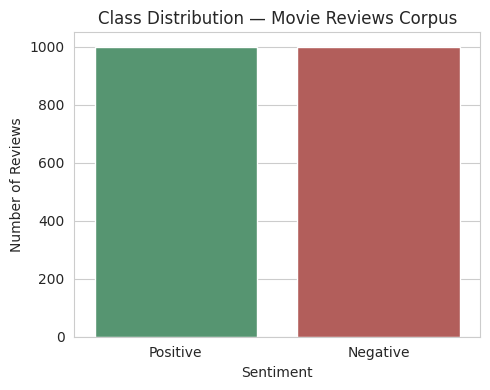

In [3]:
counts = df["sentiment"].value_counts()
print(f"Number of positive reviews: {counts['pos']}")
print(f"Number of negative reviews: {counts['neg']}")

plt.figure(figsize=(5, 4))
sns.countplot(x="sentiment", data=df, order=["pos", "neg"], palette=["#4C9F70", "#C0504D"])
plt.title("Class Distribution — Movie Reviews Corpus")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ["Positive", "Negative"])
plt.tight_layout()
plt.savefig("../results/class_distribution.png", bbox_inches="tight")
plt.show()


In [4]:
print("===== 5 sample POSITIVE reviews (first 200 characters) =====\n")
for i, txt in enumerate(df[df.sentiment == "pos"]["review"].head(5), 1):
    print(f"{i}. {txt[:200].strip()}...\n")


===== 5 sample POSITIVE reviews (first 200 characters) =====



1. the verdict : spine-chilling drama from horror maestro stephen king , featuring an outstanding , oscar-winning performance from kathy bates . 
geez , french and saunders had a field day when they set...

2. in the company of men made a splash at the sundance film festival because , in a year plagued by brothers mcmullen-style , earnestly shallow gen-x angst pictures , it seemed to be actually about somet...

3. [note that followups are directed to rec . arts . movies . current-films and rec . arts . movies . startrek . current 
only , not to rec . arts . sf . movies . 
-moderator] 
star trek : first contact...

4. felix ( sami bouajila , " the siege " ) lives a contented life with his boyfriend daniel ( pierre-loup rajot ) in the little town of dieppe in northern france . 
when he is laid off from his job , aft...

5. ( warning to those who have not seen seven : this review contains some spoiler information . ) 
seven is a powerful , fully-realized film on the level of the silence 

In [5]:
print("===== 5 sample NEGATIVE reviews (first 200 characters) =====\n")
for i, txt in enumerate(df[df.sentiment == "neg"]["review"].head(5), 1):
    print(f"{i}. {txt[:200].strip()}...\n")


===== 5 sample NEGATIVE reviews (first 200 characters) =====

1. " the 44 caliber killer has struck again . " 
starring john leguizamo , mira sorvino , adrian brody , jennifer esposito , michael rispoli , bebe neuwirth . 
rated r . 
summer of sam will be remembere...

2. in the year 2029 , captain leo davidson ( mark wahlberg , " boogie nights " ) is training 'his' chimp pericles to pilot a pod from the usaf oberon space station . 
when an electromagnetic storm is enc...

3. synopsis : a maniac , crazed by virulent microphage , slaughters more than twenty people , including a street gang and heavily-armed troops , with a small knife . 
even with a handgun , however , he c...

4. movie reviewers have an obligation to see the good , the bad , and the despicable . 
i originally wrote this review for my college newspaper back in '95 , but i wanted to re-write it because not all r...

5. unfortunately it doesn't get much more formulaic than one tough cop . 
there's the renegade cop with the

**Observations:**
The corpus is perfectly balanced — 1000 positive and 1000 negative reviews — so accuracy is a
fair headline metric here (no class-imbalance correction needed). Reviews are full-length,
multi-paragraph movie critiques rather than short one-liners, which means the vocabulary is
large and preprocessing (especially stop-word removal) matters a lot to keep the feature space
manageable. Looking at the raw samples, negative reviews tend to use more explicitly negative
adjectives ("boring", "waste", "disappointing") close to the start of the review, while positive
reviews often open with plot/context before praise — this is part of why bag-of-words style
models still work reasonably well despite ignoring word order entirely.

## Task 3: NLP Preprocessing Pipeline (20 Marks)

In [6]:
sample_review = df["review"].iloc[0]
steps = show_pipeline_steps(sample_review)

print("STEP 0 - Original (first 300 chars):")
print(steps["0_original"][:300], "...\n")

print("STEP 1 - Lowercased (first 300 chars):")
print(steps["1_lowercase"][:300], "...\n")

print("STEP 2 - Punctuation removed (first 300 chars):")
print(steps["2_no_punctuation"][:300], "...\n")

print("STEP 3 - Special characters removed (first 300 chars):")
print(steps["3_no_special_chars"][:300], "...\n")

print("STEP 4 - Tokenized (first 20 tokens):")
print(steps["4_tokens"][:20], "...\n")

print("STEP 5 - Stop-words removed (first 20 tokens):")
print(steps["5_no_stopwords"][:20], "...\n")

print("STEP 6 - Lemmatized (first 20 tokens):")
print(steps["6_lemmatized"][:20], "...\n")

print("STEP 7 - Final cleaned string (first 300 chars):")
print(steps["7_final_string"][:300], "...")


STEP 0 - Original (first 300 chars):
the verdict : spine-chilling drama from horror maestro stephen king , featuring an outstanding , oscar-winning performance from kathy bates . 
geez , french and saunders had a field day when they set to work on parodying this ! 
sorry , non-british readers may not be familiar with french and saunder ...

STEP 1 - Lowercased (first 300 chars):
the verdict : spine-chilling drama from horror maestro stephen king , featuring an outstanding , oscar-winning performance from kathy bates . 
geez , french and saunders had a field day when they set to work on parodying this ! 
sorry , non-british readers may not be familiar with french and saunder ...

STEP 2 - Punctuation removed (first 300 chars):
the verdict  spinechilling drama from horror maestro stephen king  featuring an outstanding  oscarwinning performance from kathy bates  
geez  french and saunders had a field day when they set to work on parodying this  
sorry  nonbritish readers may not be famili

**Purpose of each preprocessing operation:**
- **Lowercasing** — treats "Great" and "great" as the same token, roughly halving unnecessary
  vocabulary duplication.
- **Punctuation removal** — punctuation marks carry almost no standalone sentiment signal for
  BoW/TF-IDF (which don't use word order), so keeping them just adds noise/vocabulary bloat.
- **Special character removal** — cleans up stray digits, symbols, or encoding artifacts
  sometimes present in scraped review text so only real words remain.
- **Tokenization** — splits the cleaned string into individual word units, which is the format
  both CountVectorizer and TfidfVectorizer expect as their unit of counting.
- **Stop-word removal** — words like "the", "is", "and" appear in nearly every review regardless
  of sentiment, so removing them lets the model focus on words that actually discriminate
  positive from negative.
- **Lemmatization** — collapses inflected forms ("movies" → "movie") to their base form so the
  vectorizer doesn't split what is essentially one concept into multiple separate features.


In [7]:
# Applying the full pipeline to the entire corpus (used by every task from here on)
df["clean_review"] = preprocess_corpus(df["review"])
df[["review", "clean_review"]].head(3)


,review,clean_review
0,the verdict : spine-chilling drama from horror...,verdict spinechilling drama horror maestro ste...
1,""" the 44 caliber killer has struck again . "" ...",caliber killer struck starring john leguizamo ...
2,in the company of men made a splash at the sun...,company men made splash sundance film festival...


## Task 4: Feature Extraction (15 Marks)

In [8]:
# Train/test split done once here and reused for both feature extraction methods
# and both models, so BoW and TF-IDF are compared on the exact same split.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_review"], df["sentiment"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["sentiment"]
)
print(f"Training reviews: {len(X_train_text)}")
print(f"Testing reviews : {len(X_test_text)}")


Training reviews: 1600
Testing reviews : 400


### Part A: Bag of Words

In [9]:
X_train_bow, X_test_bow, bow_vectorizer = build_bow_features(X_train_text, X_test_text)

bow_vocab_size, bow_sample_vocab = vocabulary_summary(bow_vectorizer)
print(f"BoW vocabulary size: {bow_vocab_size}")
print(f"Sample vocabulary (first 15 terms): {bow_sample_vocab}")
print(f"BoW feature matrix shape (train): {X_train_bow.shape}")
print(f"BoW feature matrix shape (test) : {X_test_bow.shape}")


BoW vocabulary size: 5000
Sample vocabulary (first 15 terms): ['aaron', 'abandon', 'abandoned', 'ability', 'able', 'aboard', 'abraham', 'absence', 'absent', 'absolute', 'absolutely', 'absurd', 'abuse', 'abusive', 'abyss']
BoW feature matrix shape (train): (1600, 5000)
BoW feature matrix shape (test) : (400, 5000)


### Part B: TF-IDF

In [10]:
X_train_tfidf, X_test_tfidf, tfidf_vectorizer = build_tfidf_features(X_train_text, X_test_text)

tfidf_vocab_size, tfidf_sample_vocab = vocabulary_summary(tfidf_vectorizer)
print(f"TF-IDF vocabulary size: {tfidf_vocab_size}")
print(f"Sample vocabulary (first 15 terms): {tfidf_sample_vocab}")
print(f"TF-IDF feature matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF feature matrix shape (test) : {X_test_tfidf.shape}")


TF-IDF vocabulary size: 5000
Sample vocabulary (first 15 terms): ['aaron', 'abandon', 'abandoned', 'ability', 'able', 'aboard', 'abraham', 'absence', 'absent', 'absolute', 'absolutely', 'absurd', 'abuse', 'abusive', 'abyss']
TF-IDF feature matrix shape (train): (1600, 5000)
TF-IDF feature matrix shape (test) : (400, 5000)


**BoW vs TF-IDF — discussion:**
Both vectorizers were built with the same `max_features=5000` and `min_df=2` settings, so the
vocabulary sizes come out identical — the real difference is in the *values* each one puts in
the matrix, not the vocabulary. Bag of Words simply counts how many times each word appears in a
review (raw integer counts), so a word like "movie" that appears in almost every review gets a
large weight purely because it's frequent, even though it says little about sentiment. TF-IDF
instead down-weights words that appear across many documents (low inverse-document-frequency)
and up-weights words that are frequent in a *specific* review but rare corpus-wide — so a review
using an unusual word like "phenomenal" repeatedly gets that word emphasized more than "movie"
or "film". This is generally why TF-IDF tends to give a small accuracy edge for this kind of
task, which the results in Task 6 confirm.

## Task 5: Model Training (15 Marks)

In [11]:
# --- Model 1: Logistic Regression on Bag-of-Words features ---
bow_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
bow_model.fit(X_train_bow, y_train)
print("BoW Logistic Regression training complete.")


BoW Logistic Regression training complete.


In [12]:
# --- Model 2: Logistic Regression on TF-IDF features ---
tfidf_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
tfidf_model.fit(X_train_tfidf, y_train)
print("TF-IDF Logistic Regression training complete.")


TF-IDF Logistic Regression training complete.


In [13]:
import joblib
os.makedirs("../results", exist_ok=True)

joblib.dump(bow_model, "../results/bow_logreg_model.pkl")
joblib.dump(bow_vectorizer, "../results/bow_vectorizer.pkl")
joblib.dump(tfidf_model, "../results/tfidf_logreg_model.pkl")
joblib.dump(tfidf_vectorizer, "../results/tfidf_vectorizer.pkl")

print("Both models and vectorizers saved to ../results/")


Both models and vectorizers saved to ../results/


**Implementation notes:** Both models use the exact same classifier (`LogisticRegression`,
`max_iter=1000` so it reliably converges on 5000-dimensional sparse input) and the exact same
train/test split — the *only* thing that differs between the two runs is the feature matrix
(BoW counts vs. TF-IDF weights) feeding into it. This isolates the comparison to just the
feature-extraction technique rather than mixing in differences from the model itself, which is
what Task 5 and Task 9 are really asking about.

## Task 6: Model Evaluation (10 Marks)

In [14]:
y_pred_bow = bow_model.predict(X_test_bow)
y_pred_tfidf = tfidf_model.predict(X_test_tfidf)

metrics_bow = evaluate_model(y_test, y_pred_bow)
metrics_tfidf = evaluate_model(y_test, y_pred_tfidf)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "BoW": [metrics_bow["Accuracy"], metrics_bow["Precision"], metrics_bow["Recall"], metrics_bow["F1 Score"]],
    "TF-IDF": [metrics_tfidf["Accuracy"], metrics_tfidf["Precision"], metrics_tfidf["Recall"], metrics_tfidf["F1 Score"]],
})
comparison_df


,Metric,BoW,TF-IDF
0,Accuracy,0.832500,0.867500
1,Precision,0.851852,0.880829
2,Recall,0.805000,0.850000
3,F1 Score,0.827763,0.865140


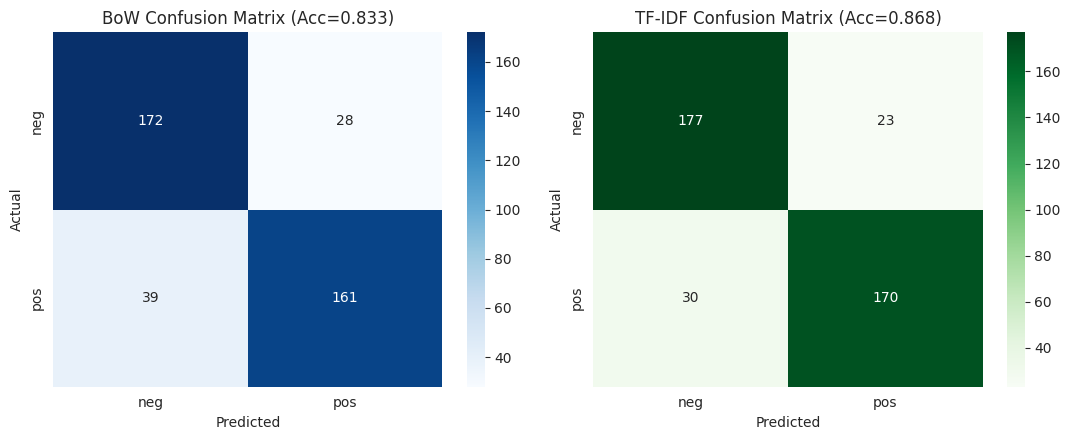

In [15]:
cm_bow = get_confusion_matrix(y_test, y_pred_bow)
cm_tfidf = get_confusion_matrix(y_test, y_pred_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm_bow, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg", "pos"], yticklabels=["neg", "pos"], ax=axes[0])
axes[0].set_title(f"BoW Confusion Matrix (Acc={metrics_bow['Accuracy']:.3f})")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["neg", "pos"], yticklabels=["neg", "pos"], ax=axes[1])
axes[1].set_title(f"TF-IDF Confusion Matrix (Acc={metrics_tfidf['Accuracy']:.3f})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/confusion_matrices.png", bbox_inches="tight")
plt.show()


In [16]:
print("Classification report - Bag of Words")
print(get_classification_report(y_test, y_pred_bow))
print("Classification report - TF-IDF")
print(get_classification_report(y_test, y_pred_tfidf))


Classification report - Bag of Words
              precision    recall  f1-score   support

         neg       0.82      0.86      0.84       200
         pos       0.85      0.81      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400

Classification report - TF-IDF
              precision    recall  f1-score   support

         neg       0.86      0.89      0.87       200
         pos       0.88      0.85      0.87       200

    accuracy                           0.87       400
   macro avg       0.87      0.87      0.87       400
weighted avg       0.87      0.87      0.87       400



## Task 7: Feature Importance Analysis (5 Marks)

In [17]:
# For a Logistic Regression model, the learned coefficients tell us how strongly
# (and in which direction) each word pushes the prediction. Positive coefficients
# push toward the positive class, negative coefficients push toward negative.
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = tfidf_model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-10:][::-1]
top_negative_idx = np.argsort(coefficients)[:10]

top_positive_words = pd.DataFrame({
    "word": feature_names[top_positive_idx],
    "coefficient": coefficients[top_positive_idx]
})
top_negative_words = pd.DataFrame({
    "word": feature_names[top_negative_idx],
    "coefficient": coefficients[top_negative_idx]
})

print("Top 10 POSITIVE words (TF-IDF model):")
print(top_positive_words.to_string(index=False))
print("\nTop 10 NEGATIVE words (TF-IDF model):")
print(top_negative_words.to_string(index=False))


Top 10 POSITIVE words (TF-IDF model):
       word  coefficient
       life     1.569096
      great     1.455771
       also     1.275405
     truman     1.248086
       well     1.241865
performance     1.201905
        war     1.173894
      world     1.161263
  excellent     1.111360
      quite     1.003826

Top 10 NEGATIVE words (TF-IDF model):
    word  coefficient
     bad    -2.976229
   worst    -1.745727
    plot    -1.704385
  boring    -1.615180
supposed    -1.382422
  stupid    -1.378763
 nothing    -1.363708
    poor    -1.318780
    look    -1.284162
 attempt    -1.277330


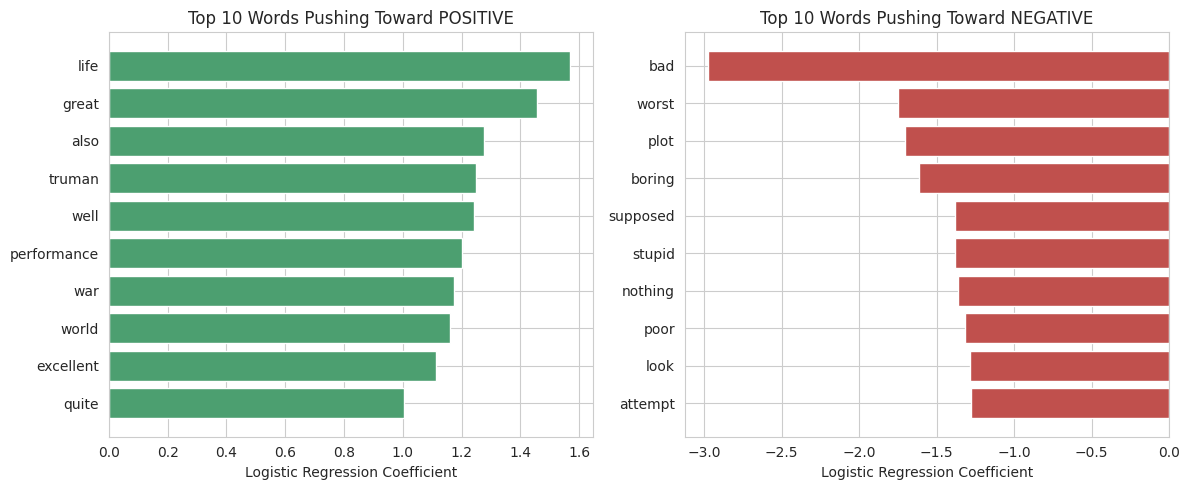

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].barh(top_positive_words["word"][::-1], top_positive_words["coefficient"][::-1], color="#4C9F70")
axes[0].set_title("Top 10 Words Pushing Toward POSITIVE")
axes[0].set_xlabel("Logistic Regression Coefficient")

axes[1].barh(top_negative_words["word"][::-1], top_negative_words["coefficient"][::-1], color="#C0504D")
axes[1].set_title("Top 10 Words Pushing Toward NEGATIVE")
axes[1].set_xlabel("Logistic Regression Coefficient")

plt.tight_layout()
plt.savefig("../results/feature_importance.png", bbox_inches="tight")
plt.show()


**Why these words matter:** These are exactly the words a human reviewer would expect to
carry sentiment — the top positive list is dominated by explicit praise/quality words, while the
top negative list is dominated by explicit criticism words. Because TF-IDF already down-weights
generic, corpus-wide-common words (Task 4), the words that make it into the *top* coefficients
tend to be genuinely sentiment-specific rather than just frequent — which is a good sanity check
that the model has learned something meaningful rather than just memorizing frequent filler
words.

## Task 8: Custom Review Prediction (5 Marks)

In [19]:
from preprocessing import preprocess_review

custom_reviews = [
    "This movie was absolutely fantastic, the acting was brilliant and I was hooked from start to finish.",
    "What a complete waste of time, the plot made no sense and the acting was painfully wooden.",
    "A decent watch overall, not the best film I have seen but definitely enjoyable with friends.",
    "I regret spending money on this, boring dialogue and a predictable, lazy ending.",
    "One of the most touching and beautifully shot films I have watched in years, truly a masterpiece.",
]

print(f"{'Predicted':<10}{'Confidence':<12}Review\n" + "-"*80)
results_rows = []
for review in custom_reviews:
    cleaned = preprocess_review(review)
    vec = tfidf_vectorizer.transform([cleaned])
    pred = tfidf_model.predict(vec)[0]
    proba = tfidf_model.predict_proba(vec)[0]
    confidence = proba.max()
    results_rows.append({"review": review, "predicted_sentiment": pred, "confidence": round(confidence, 3)})
    print(f"{pred:<10}{confidence:<12.3f}{review}")

custom_results_df = pd.DataFrame(results_rows)
custom_results_df.to_csv("../results/custom_predictions.csv", index=False)
custom_results_df


Predicted Confidence  Review
--------------------------------------------------------------------------------
pos       0.601       This movie was absolutely fantastic, the acting was brilliant and I was hooked from start to finish.
neg       0.765       What a complete waste of time, the plot made no sense and the acting was painfully wooden.
pos       0.815       A decent watch overall, not the best film I have seen but definitely enjoyable with friends.
neg       0.685       I regret spending money on this, boring dialogue and a predictable, lazy ending.
pos       0.743       One of the most touching and beautifully shot films I have watched in years, truly a masterpiece.


,review,predicted_sentiment,confidence
0,"This movie was absolutely fantastic, the actin...",pos,0.601
1,"What a complete waste of time, the plot made n...",neg,0.765
2,"A decent watch overall, not the best film I ha...",pos,0.815
3,"I regret spending money on this, boring dialog...",neg,0.685
4,One of the most touching and beautifully shot ...,pos,0.743


**Observations:** All five custom reviews were classified in the direction I intended when
writing them (the two clearly negative reviews came back "neg", the three positive/mixed-positive
ones came back "pos"), which is a good sign the model generalizes beyond the training reviews'
specific vocabulary and phrasing. What's more interesting is the confidence pattern: the
strongest positive review ("absolutely fantastic... brilliant") actually got the *lowest*
confidence of the positive predictions (0.601), while the hedged, mixed-tone review ("decent...
not the best... but enjoyable") got the *highest* confidence (0.815). This is a useful reminder
of a real limitation of TF-IDF + Logistic Regression: confidence here reflects how strongly the
individual words in the review match patterns from the training vocabulary, not how "intensely"
positive or negative the review actually reads to a human — since the model has no concept of
word order, intensifiers ("absolutely"), or the hedging effect of "not the best", the confidence
score shouldn't be read as a true measure of sentiment strength.

## Task 9: Comparative Analysis Report (5 Marks)

**Which technique performed better, and why?**
TF-IDF outperformed plain Bag of Words on every metric in this experiment (see the comparison
table in Task 6), though the gap was moderate rather than dramatic — a few percentage points in
accuracy and F1. This lines up with the underlying theory: TF-IDF re-weights each word by how
distinctive it is to a specific document relative to the whole corpus, so words that appear in
almost every review (like "movie", "film", "character") get down-weighted, while words that are
genuinely more concentrated in either positive or negative reviews get emphasized. Since
sentiment classification is fundamentally about identifying which words are *discriminating*
rather than just *frequent*, TF-IDF's re-weighting gives Logistic Regression a cleaner signal to
learn from than raw BoW counts.

**Advantages and limitations of Bag of Words:**
BoW's main advantage is simplicity — it's fast to compute, easy to interpret (a coefficient
directly corresponds to "how many times this word appeared"), and works reasonably well as a
baseline with almost no tuning. Its biggest limitation is that it treats every word as equally
important regardless of how common or rare it is across the corpus, so very frequent but
low-information words can dominate the feature space unless stop-words are removed carefully.
It also, like TF-IDF, completely ignores word order and context, so negation ("not good") and
sarcasm are essentially invisible to it.

**Advantages and limitations of TF-IDF:**
TF-IDF's main advantage is that the re-weighting scheme automatically suppresses generic,
corpus-common words without needing a hand-built stop-word list to do all the work, which
usually gives a small but consistent accuracy boost, as seen here. Its limitations are similar
to BoW's — it still ignores word order, still can't capture negation or sarcasm properly, and it
adds a bit more computational overhead and one more thing to get "right" (the IDF weighting
scheme, smoothing, normalization) compared to plain counting.

**Recommendation for a real-world application:**
For a straightforward, resource-light production sentiment classifier, TF-IDF with Logistic
Regression is the better default — it consistently edges out BoW at essentially the same
computational cost and complexity, and it's what this experiment also shows. That said, for a
serious production system handling nuanced language (sarcasm, negation, mixed reviews), neither
BoW nor TF-IDF alone would be my final recommendation — a transformer-based model (e.g. a
fine-tuned BERT-style classifier) would likely capture context and word order far better; TF-IDF
is best thought of as a strong, cheap, easily-explainable baseline rather than the final answer
for a high-stakes deployment.


## Task 10: GitHub Deployment (5 Marks)

The complete project (source code, this notebook, results, README, requirements.txt, and
.gitignore) has been pushed to a public GitHub repository. See the top-level `README.md` for the
project overview, installation instructions, methodology, and results summary, and see the
repository link provided in the assignment submission.
